<a href="https://colab.research.google.com/github/Moreno0987/excel.github.io/blob/main/UTS_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving housing_price_dataset.csv to housing_price_dataset (1).csv


Pada tahap ini dilakukan proses upload dataset ke Google Colab menggunakan library google.colab.
Dataset yang sebelumnya disimpan secara lokal akan diunggah agar dapat diakses dan diproses menggunakan Python.

In [3]:
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


Pada tahap ini dataset dibaca menggunakan library Pandas dengan fungsi read_csv().
Data yang telah di-upload kemudian disimpan ke dalam variabel df untuk diproses lebih lanjut.
Perintah df.head() digunakan untuk menampilkan beberapa baris pertama dari dataset guna memastikan data berhasil dimuat dengan benar.

In [4]:
df.info()
df.head()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


,0
SquareFeet,0
Bedrooms,0
Bathrooms,0
Neighborhood,0
YearBuilt,0
Price,0


Pada tahap ini dilakukan pengecekan awal terhadap dataset menggunakan beberapa fungsi dari Pandas.
df.info() digunakan untuk melihat informasi umum seperti jumlah data, tipe data, dan jumlah nilai non-null.
df.head() menampilkan beberapa baris pertama untuk memahami isi data secara sekilas.
df.isnull().sum() digunakan untuk mengecek apakah terdapat missing value pada setiap kolom.

In [5]:
 # STATISTIK DESKRIPTIF

df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


Pada tahap ini dilakukan analisis statistik deskriptif menggunakan df.describe().
Fungsi ini menampilkan ringkasan data numerik seperti nilai rata-rata (mean), minimum, maksimum, dan standar deviasi.
Tujuannya adalah untuk memahami karakteristik data serta mendeteksi kemungkinan adanya nilai yang tidak normal.

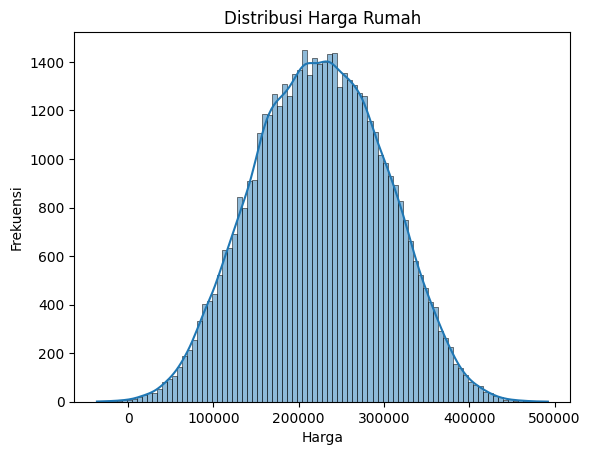

In [6]:
# — DISTRIBUSI TARGET (PRICE)

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], kde=True)
plt.title("Distribusi Harga Rumah")
plt.xlabel("Harga")
plt.ylabel("Frekuensi")
plt.show()

Pada tahap ini dilakukan visualisasi distribusi target (Price) menggunakan histogram.
Grafik ini digunakan untuk melihat pola penyebaran harga rumah, apakah data terdistribusi normal atau tidak.
Informasi ini penting untuk memahami karakteristik data dan sebagai dasar dalam analisis serta pemodelan selanjutnya.

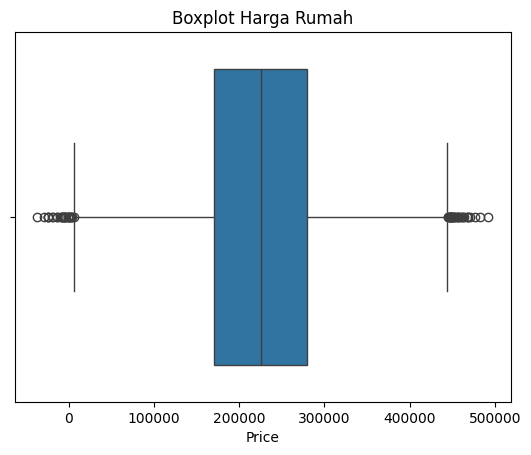

In [7]:
# — DETEKSI OUTLIER

sns.boxplot(x=df['Price'])
plt.title("Boxplot Harga Rumah")
plt.show()

Pada tahap ini digunakan boxplot untuk mendeteksi adanya outlier pada data harga rumah (Price).
Outlier merupakan nilai yang jauh dari rentang normal dan dapat mempengaruhi hasil model.
Dengan visualisasi ini, dapat diketahui apakah terdapat data ekstrem yang perlu ditangani pada tahap selanjutnya.

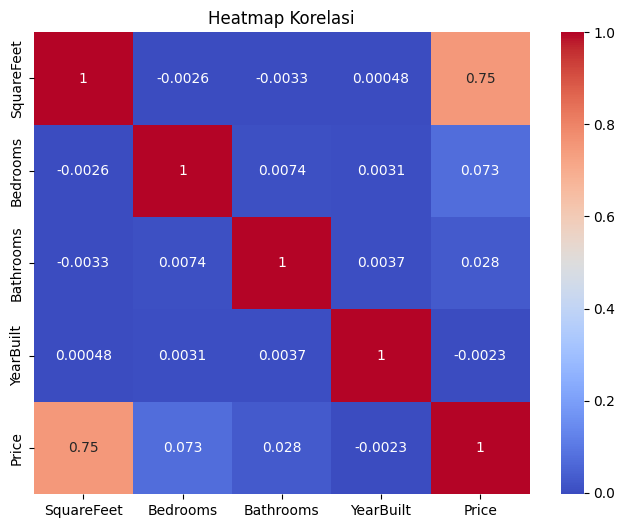

In [8]:
# — KORELASI

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

Pada tahap ini dilakukan analisis korelasi antar variabel numerik menggunakan heatmap.
Visualisasi ini membantu melihat hubungan antar fitur serta tingkat pengaruhnya terhadap variabel target (Price).
Nilai korelasi yang mendekati 1 atau -1 menunjukkan hubungan yang kuat, sehingga fitur tersebut dapat dipertimbangkan dalam pemodelan.

In [9]:
# — CEK DATA KATEGORIKAL

df['Neighborhood'].value_counts()

,count
Neighborhood,
Suburb,16721
Rural,16676
Urban,16603



Pada tahap ini dilakukan pengecekan distribusi data pada kategori lokasi rumah (Neighborhood).
Data lokasi telah terbagi menjadi beberapa kategori seperti Suburb, Rural, dan Urban.
Analisis ini bertujuan untuk memahami persebaran data pada setiap kategori serta memastikan bahwa data kategorikal telah siap digunakan atau diolah lebih lanjut dalam proses Machine Learning.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


Berdasarkan hasil df.info(), dataset memiliki 50.000 baris dan 6 kolom.
Seluruh kolom memiliki jumlah data lengkap (tidak terdapat missing value), sehingga data sudah bersih untuk tahap awal analisis.

Tipe data pada dataset terdiri dari:

int64 → SquareFeet, Bedrooms, Bathrooms, YearBuilt (fitur numerik)
float64 → Price (target variabel)
object → Neighborhood (data kategorikal)

Kolom Neighborhood masih berupa data kategorikal sehingga perlu dilakukan encoding sebelum digunakan dalam model Machine Learning.

In [25]:
df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)

In [26]:
df.columns

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price', 'age',
       'Neighborhood_Suburb', 'Neighborhood_Urban'],
      dtype='object')

In [27]:
print(df.columns)

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price', 'age',
       'Neighborhood_Suburb', 'Neighborhood_Urban'],
      dtype='object')


Dari output `df.columns`, Anda akan melihat bahwa kolom `Neighborhood` telah digantikan oleh `Neighborhood_Suburb` dan `Neighborhood_Urban`. Ini menunjukkan bahwa _encoding_ sudah sukses, dan Anda bisa menggunakan kolom-kolom baru ini untuk pemodelan atau analisis selanjutnya.

In [28]:
# CEK MISSING VALUE

df.isnull().sum()

,0
SquareFeet,0
Bedrooms,0
Bathrooms,0
YearBuilt,0
Price,0
age,0
Neighborhood_Suburb,0
Neighborhood_Urban,0


Pada tahap ini dilakukan pengecekan kembali terhadap missing value setelah proses preprocessing.
Hal ini bertujuan untuk memastikan bahwa tidak ada data kosong yang dapat mempengaruhi hasil model.
Jika seluruh nilai bernilai 0, maka dataset sudah bersih dan siap digunakan untuk tahap pemodelan.

In [29]:
# — BUAT FITUR BARU

df['age'] = 2026 - df['YearBuilt']

Pada tahap ini dilakukan pembuatan fitur baru yaitu age yang merepresentasikan umur bangunan.
Fitur ini dihitung dari selisih antara tahun saat ini (2026) dengan tahun pembangunan (YearBuilt).
Penambahan fitur ini bertujuan untuk memberikan informasi tambahan yang dapat membantu model dalam memprediksi harga rumah, karena umur bangunan dapat mempengaruhi nilai properti.

In [14]:
# — PISAHKAN FITUR & TARGET

X = df.drop('Price', axis=1)
y = df['Price']

Pada tahap ini dataset dipisahkan menjadi fitur (X) dan target (y).
Fitur (X) berisi seluruh variabel independen yang digunakan untuk memprediksi, sedangkan target (y) adalah variabel yang ingin diprediksi yaitu Price.
Pemisahan ini penting agar model dapat belajar hubungan antara fitur dan target secara tepat.

In [30]:
# — TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Pada tahap ini dataset dibagi menjadi data training dan data testing menggunakan metode train_test_split.
Sebanyak 80% data digunakan untuk melatih model, sedangkan 20% sisanya digunakan untuk menguji performa model.
Pembagian ini bertujuan agar model dapat dievaluasi menggunakan data yang belum pernah dilihat sebelumnya, sehingga hasil evaluasi lebih objektif.
Parameter random_state=42 digunakan agar pembagian data bersifat konsisten dan dapat direproduksi.

In [32]:
# — SCALING

from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported for get_dummies

scaler = StandardScaler()

# Perform one-hot encoding on 'Neighborhood' column for X_train and X_test
# This converts the categorical string column into numerical columns
X_train = pd.get_dummies(X_train, columns=['Neighborhood'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Neighborhood'], drop_first=True)

# Now all columns in X_train and X_test should be numerical,
# so StandardScaler can process them
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Pada tahap ini dilakukan proses feature scaling menggunakan StandardScaler.
Scaling bertujuan untuk menyamakan skala antar fitur agar model tidak bias terhadap fitur dengan nilai yang lebih besar.
Proses fit dilakukan pada data training untuk menghitung parameter skala, kemudian diterapkan pada data testing menggunakan transform agar tidak terjadi kebocoran data (data leakage).

In [33]:
# MODELING — SIMPLE LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

X_simple = df[['SquareFeet']]
y_simple = df['Price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

Pada tahap ini dilakukan pemodelan menggunakan Simple Linear Regression dengan satu fitur yaitu SquareFeet.
Model ini bertujuan untuk mengetahui hubungan antara luas bangunan dengan harga rumah.
Dataset dibagi menjadi data training dan testing dengan rasio 80:20, kemudian model dilatih menggunakan data training dan digunakan untuk memprediksi data testing.
Hasil dari model ini akan digunakan sebagai pembanding dengan model Multiple Linear Regression.

In [20]:
# — EVALUASI SIMPLE

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_s, y_pred_s)
rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2 = r2_score(y_test_s, y_pred_s)

print("Simple Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


Simple Regression
MAE: 39675.18288748062
RMSE: 49661.77503452086
R2: 0.5703289305615942


Pada tahap ini dilakukan evaluasi terhadap model Simple Linear Regression menggunakan tiga metrik, yaitu MAE, RMSE, dan R².
MAE (Mean Absolute Error) mengukur rata-rata selisih antara nilai prediksi dan nilai aktual.
RMSE (Root Mean Squared Error) mengukur error dengan memberikan penalti lebih besar pada kesalahan yang besar.
R² (R-squared) menunjukkan seberapa baik model dalam menjelaskan variasi data.
Evaluasi ini digunakan untuk mengetahui seberapa akurat model dalam memprediksi harga rumah.


In [21]:
# — MULTIPLE LINEAR REGRESSION

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Pada tahap ini dilakukan pemodelan menggunakan Multiple Linear Regression dengan memanfaatkan lebih dari satu fitur.
Model dilatih menggunakan data training (X_train dan y_train) untuk mempelajari hubungan antara berbagai fitur dengan harga rumah.
Setelah itu, model digunakan untuk melakukan prediksi terhadap data testing (X_test) untuk menghasilkan nilai prediksi (y_pred).
Pendekatan ini diharapkan memberikan hasil yang lebih akurat dibandingkan Simple Linear Regression karena mempertimbangkan lebih banyak faktor.

In [22]:
# — EVALUASI MULTIPLE

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Multiple Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Multiple Regression
MAE: 39430.16533829791
RMSE: 49358.376911191546
R2: 0.5755628630306235


Pada tahap ini dilakukan evaluasi terhadap model Multiple Linear Regression menggunakan tiga metrik, yaitu MAE, RMSE, dan R².
MAE digunakan untuk mengukur rata-rata kesalahan absolut antara nilai aktual dan prediksi.
RMSE memberikan penalti lebih besar terhadap kesalahan yang besar sehingga sensitif terhadap outlier.
R² digunakan untuk mengetahui seberapa besar variasi data yang dapat dijelaskan oleh model.
Hasil evaluasi ini kemudian dibandingkan dengan Simple Linear Regression untuk mengetahui model mana yang memiliki performa lebih baik.

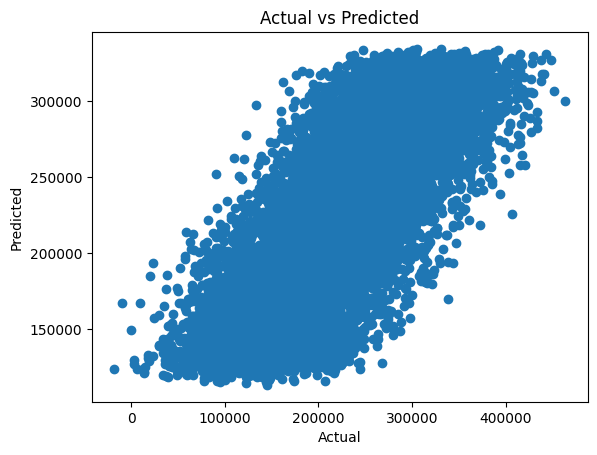

In [23]:
# — SCATTER ACTUAL VS PREDICTED

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Pada tahap ini dilakukan visualisasi perbandingan antara nilai aktual (y_test) dan nilai prediksi (y_pred) menggunakan scatter plot.
Grafik ini digunakan untuk melihat seberapa dekat hasil prediksi model dengan nilai sebenarnya.
Semakin dekat titik-titik terhadap garis diagonal, maka semakin baik performa model dalam melakukan prediksi

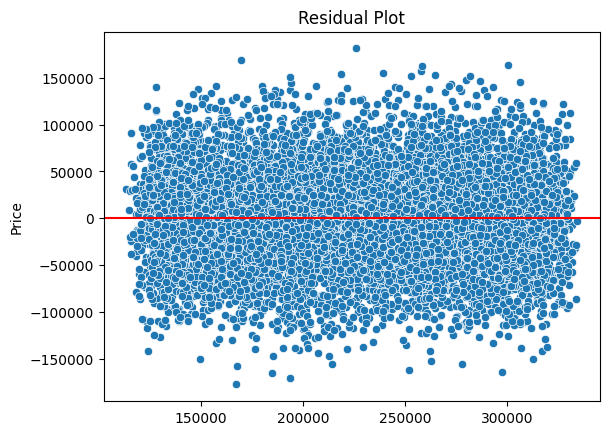

In [24]:
# — RESIDUAL PLOT

residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

Residual merupakan selisih antara nilai aktual (y_test) dan nilai prediksi (y_pred).
Visualisasi ini digunakan untuk melihat pola penyebaran error terhadap hasil prediksi.

Jika model bekerja dengan baik, maka residual akan tersebar secara acak di sekitar garis nol (horizontal) tanpa membentuk pola tertentu.
Hal ini menunjukkan bahwa model tidak memiliki bias dan mampu menangkap pola data dengan baik.

Sebaliknya, jika terdapat pola tertentu (misalnya membentuk kurva atau tren), maka hal tersebut menunjukkan bahwa model belum mampu menangkap hubungan data secara optimal dan masih terdapat kesalahan sistematis.

Berdasarkan residual plot, terlihat bahwa nilai residual tersebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Hal ini menunjukkan bahwa model regresi yang digunakan sudah cukup baik dalam menangkap hubungan linear antar variabel.
Namun, masih terdapat penyebaran residual yang cukup lebar, yang mengindikasikan bahwa model belum sepenuhnya akurat dan masih terdapat error dalam prediksi.

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan, dapat disimpulkan bahwa:

Fitur seperti luas bangunan, jumlah kamar, dan lokasi memiliki pengaruh terhadap harga rumah.
Model Multiple Linear Regression memberikan performa yang lebih baik dibandingkan Simple Linear Regression karena mempertimbangkan lebih banyak variabel.
Evaluasi menggunakan MAE, RMSE, dan R² menunjukkan bahwa model mampu melakukan prediksi dengan cukup baik, meskipun masih terdapat error yang cukup besar.
Visualisasi residual menunjukkan bahwa model sudah cukup sesuai dengan asumsi regresi linear, namun masih dapat ditingkatkan.